In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import re
import time
from pathlib import Path
DATA_DIR = Path('/content/drive/MyDrive/576 project')

**DATA CLEANING**

In [ ]:
regular = pd.read_csv(DATA_DIR / 'MRegularSeasonDetailedResults.csv')
tourney_compact = pd.read_csv(DATA_DIR / 'MNCAATourneyCompactResults.csv')
tourney_detailed = pd.read_csv(DATA_DIR / 'MNCAATourneyDetailedResults.csv')
seeds = pd.read_csv(DATA_DIR / 'MNCAATourneySeeds.csv')
slots = pd.read_csv(DATA_DIR / 'MNCAATourneySlots.csv')
teams = pd.read_csv(DATA_DIR / 'MTeams.csv')

In [ ]:
w_cols = {
    'WTeamID': 'TeamID',
    'WScore': 'PointsFor',
    'LTeamID': 'OppTeamID',
    'LScore': 'PointsAgainst',
    'WLoc': 'Loc',
    'NumOT': 'NumOT',
    'WFGM': 'FGM',
    'WFGA': 'FGA',
    'WFGM3': 'FGM3',
    'WFGA3': 'FGA3',
    'WFTM': 'FTM',
    'WFTA': 'FTA',
    'WOR': 'OR',
    'WDR': 'DR',
    'WAst': 'Ast',
    'WTO': 'TO',
    'WStl': 'Stl',
    'WBlk': 'Blk',
    'WPF': 'PF',
    'LFGM': 'OppFGM',
    'LFGA': 'OppFGA',
    'LFGM3': 'OppFGM3',
    'LFGA3': 'OppFGA3',
    'LFTM': 'OppFTM',
    'LFTA': 'OppFTA',
    'LOR': 'OppOR',
    'LDR': 'OppDR',
    'LAst': 'OppAst',
    'LTO': 'OppTO',
    'LStl': 'OppStl',
    'LBlk': 'OppBlk',
    'LPF': 'OppPF'
}

w_df = regular[list(['Season', 'DayNum'] + list(w_cols.keys()))].rename(columns=w_cols)
w_df['Result'] = 1

In [ ]:
def flip_loc(loc):
    if loc == 'H':
        return 'A'
    elif loc == 'A':
        return 'H'
    return 'N'

l_cols = {
    'LTeamID': 'TeamID',
    'LScore': 'PointsFor',
    'WTeamID': 'OppTeamID',
    'WScore': 'PointsAgainst',
    'WLoc': 'Loc',
    'NumOT': 'NumOT',
    'LFGM': 'FGM',
    'LFGA': 'FGA',
    'LFGM3': 'FGM3',
    'LFGA3': 'FGA3',
    'LFTM': 'FTM',
    'LFTA': 'FTA',
    'LOR': 'OR',
    'LDR': 'DR',
    'LAst': 'Ast',
    'LTO': 'TO',
    'LStl': 'Stl',
    'LBlk': 'Blk',
    'LPF': 'PF',
    'WFGM': 'OppFGM',
    'WFGA': 'OppFGA',
    'WFGM3': 'OppFGM3',
    'WFGA3': 'OppFGA3',
    'WFTM': 'OppFTM',
    'WFTA': 'OppFTA',
    'WOR': 'OppOR',
    'WDR': 'OppDR',
    'WAst': 'OppAst',
    'WTO': 'OppTO',
    'WStl': 'OppStl',
    'WBlk': 'OppBlk',
    'WPF': 'OppPF'
}

l_df = regular[list(['Season', 'DayNum'] + list(l_cols.keys()))].rename(columns=l_cols)
l_df['Loc'] = l_df['Loc'].apply(flip_loc)
l_df['Result'] = 0

In [ ]:
team_games = pd.concat([w_df, l_df], ignore_index=True)
team_games = team_games.sort_values(['Season', 'TeamID', 'DayNum']).reset_index(drop=True)

team_games.head()

,Season,DayNum,TeamID,PointsFor,OppTeamID,PointsAgainst,Loc,NumOT,FGM,FGA,...,OppFTM,OppFTA,OppOR,OppDR,OppAst,OppTO,OppStl,OppBlk,OppPF,Result
0,2003,19,1102,47,1257,65,A,0,16,40,...,14,20,13,26,12,14,8,4,23,0
1,2003,22,1102,72,1391,43,H,0,26,46,...,11,15,12,15,5,11,5,0,12,1
2,2003,25,1102,57,1117,52,A,0,16,36,...,14,21,7,17,8,8,3,0,19,1
3,2003,27,1102,47,1399,60,A,0,15,35,...,18,20,9,22,13,14,4,1,13,0
4,2003,31,1102,65,1410,44,H,0,23,40,...,7,9,11,17,7,13,3,0,13,1


**FEATURE ENGINEERING**

In [ ]:
def safe_divide(a, b):
    return np.where(b == 0, np.nan, a / b)

# Basic percentages
team_games['FG_pct'] = safe_divide(team_games['FGM'], team_games['FGA'])
team_games['FG3_pct'] = safe_divide(team_games['FGM3'], team_games['FGA3'])
team_games['FT_pct'] = safe_divide(team_games['FTM'], team_games['FTA'])

# Effective FG%
team_games['eFG_pct'] = safe_divide(team_games['FGM'] + 0.5 * team_games['FGM3'], team_games['FGA'])

# True Shooting %
team_games['TS_pct'] = safe_divide(
    team_games['PointsFor'],
    2 * (team_games['FGA'] + 0.44 * team_games['FTA'])
)

# Opponent shooting efficiency
team_games['Opp_eFG_pct'] = safe_divide(
    team_games['OppFGM'] + 0.5 * team_games['OppFGM3'],
    team_games['OppFGA']
)

# Possession estimates
team_games['Poss'] = team_games['FGA'] - team_games['OR'] + team_games['TO'] + 0.44 * team_games['FTA']
team_games['OppPoss'] = team_games['OppFGA'] - team_games['OppOR'] + team_games['OppTO'] + 0.44 * team_games['OppFTA']

# Ratings
team_games['OffRtg'] = 100 * safe_divide(team_games['PointsFor'], team_games['Poss'])
team_games['DefRtg'] = 100 * safe_divide(team_games['PointsAgainst'], team_games['OppPoss'])
team_games['NetRtg'] = team_games['OffRtg'] - team_games['DefRtg']

# Style / rate features
team_games['TO_rate'] = safe_divide(team_games['TO'], team_games['Poss'])
team_games['Ast_TO'] = safe_divide(team_games['Ast'], team_games['TO'])
team_games['FT_rate'] = safe_divide(team_games['FTA'], team_games['FGA'])
team_games['FG3A_rate'] = safe_divide(team_games['FGA3'], team_games['FGA'])

# Rebounding rates
team_games['ORR'] = safe_divide(team_games['OR'], team_games['OR'] + team_games['OppDR'])
team_games['DRR'] = safe_divide(team_games['DR'], team_games['DR'] + team_games['OppOR'])

# Margin
team_games['Margin'] = team_games['PointsFor'] - team_games['PointsAgainst']

In [ ]:
# Dominance indicators
team_games['WinBy10Plus'] = (team_games['Margin'] >= 10).astype(int)
team_games['LoseBy10Plus'] = (team_games['Margin'] <= -10).astype(int)
team_games['CloseGame'] = (team_games['Margin'].abs() <= 5).astype(int)
team_games['CloseWin'] = ((team_games['Margin'].abs() <= 5) & (team_games['Result'] == 1)).astype(int)

# Non-home performance
team_games['NeutralWin'] = ((team_games['Loc'] == 'N') & (team_games['Result'] == 1)).astype(int)
team_games['AwayWin'] = ((team_games['Loc'] == 'A') & (team_games['Result'] == 1)).astype(int)

In [ ]:
# Team form
team_games = team_games.sort_values(['Season', 'TeamID', 'DayNum']).copy()

for window in [5, 10]:
    team_games[f'Last{window}_WinPct'] = (
        team_games.groupby(['Season', 'TeamID'])['Result']
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    )

    team_games[f'Last{window}_Margin'] = (
        team_games.groupby(['Season', 'TeamID'])['Margin']
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    )

    team_games[f'Last{window}_NetRtg'] = (
        team_games.groupby(['Season', 'TeamID'])['NetRtg']
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    )

In [ ]:
# Season Averages/Stats per team
season_features = team_games.groupby(['Season', 'TeamID']).agg(
    Games=('Result', 'size'),
    Wins=('Result', 'sum'),
    WinPct=('Result', 'mean'),

    AvgPointsFor=('PointsFor', 'mean'),
    AvgPointsAgainst=('PointsAgainst', 'mean'),
    AvgMargin=('Margin', 'mean'),
    MedianMargin=('Margin', 'median'),
    MarginSD=('Margin', 'std'),

    FG_pct=('FG_pct', 'mean'),
    FG3_pct=('FG3_pct', 'mean'),
    FT_pct=('FT_pct', 'mean'),
    eFG_pct=('eFG_pct', 'mean'),
    TS_pct=('TS_pct', 'mean'),

    AvgPoss=('Poss', 'mean'),
    OffRtg=('OffRtg', 'mean'),
    DefRtg=('DefRtg', 'mean'),
    NetRtg=('NetRtg', 'mean'),

    TO_rate=('TO_rate', 'mean'),
    Ast_TO=('Ast_TO', 'mean'),
    FT_rate=('FT_rate', 'mean'),
    FG3A_rate=('FG3A_rate', 'mean'),
    ORR=('ORR', 'mean'),
    DRR=('DRR', 'mean'),

    AvgAst=('Ast', 'mean'),
    AvgTO=('TO', 'mean'),
    AvgStl=('Stl', 'mean'),
    AvgBlk=('Blk', 'mean'),
    AvgPF=('PF', 'mean'),

    WinBy10PlusPct=('WinBy10Plus', 'mean'),
    LoseBy10PlusPct=('LoseBy10Plus', 'mean'),
    CloseGamePct=('CloseGame', 'mean'),
    CloseWinPct=('CloseWin', 'mean'),

    Last5_WinPct=('Last5_WinPct', 'last'),
    Last5_Margin=('Last5_Margin', 'last'),
    Last5_NetRtg=('Last5_NetRtg', 'last'),

    Last10_WinPct=('Last10_WinPct', 'last'),
    Last10_Margin=('Last10_Margin', 'last'),
    Last10_NetRtg=('Last10_NetRtg', 'last')
).reset_index()

In [ ]:
# Strength of Schedule: average regular-season WinPct of each team's opponents
opp_winpct = season_features[['Season', 'TeamID', 'WinPct']].rename(columns={'TeamID': 'OppTeamID', 'WinPct': 'OppWinPct'})
games_with_opp = team_games.merge(opp_winpct, on=['Season', 'OppTeamID'], how='left')
sos = games_with_opp.groupby(['Season', 'TeamID']).agg(SoS=('OppWinPct', 'mean')).reset_index()
season_features = season_features.merge(sos, on=['Season', 'TeamID'], how='left')
season_features[['Season', 'TeamID', 'WinPct', 'SoS']].head()

,Season,TeamID,WinPct,SoS
0,2003,1102,0.428571,0.530644
1,2003,1103,0.481481,0.489779
2,2003,1104,0.607143,0.572492
3,2003,1105,0.269231,0.415228
4,2003,1106,0.464286,0.458062


In [ ]:
# H/A/N win %
loc_summary = team_games.pivot_table(
    index=['Season', 'TeamID'],
    columns='Loc',
    values='Result',
    aggfunc='mean'
).reset_index()

loc_summary = loc_summary.rename(columns={
    'H': 'HomeWinPct',
    'A': 'AwayWinPct',
    'N': 'NeutralWinPct'
})

season_features = season_features.merge(loc_summary, on=['Season', 'TeamID'], how='left')

In [ ]:
def extract_seed_num(seed_str):
    match = re.search(r'(\d+)', str(seed_str))
    return int(match.group(1)) if match else np.nan

seeds['SeedNum'] = seeds['Seed'].apply(extract_seed_num)
seeds.head()

,Season,Seed,TeamID,SeedNum
0,1985,W01,1207,1
1,1985,W02,1210,2
2,1985,W03,1228,3
3,1985,W04,1260,4
4,1985,W05,1374,5


In [ ]:
season_features = season_features.merge(
    seeds[['Season', 'TeamID', 'Seed', 'SeedNum']],
    on=['Season', 'TeamID'],
    how='left'
)

season_features.head()

,Season,TeamID,Games,Wins,WinPct,AvgPointsFor,AvgPointsAgainst,AvgMargin,MedianMargin,MarginSD,...,Last5_NetRtg,Last10_WinPct,Last10_Margin,Last10_NetRtg,SoS,AwayWinPct,HomeWinPct,NeutralWinPct,Seed,SeedNum
0,2003,1102,28,12,0.428571,57.250000,57.000000,0.250000,-3.0,16.169530,...,-10.521843,0.2,-8.6,-17.870918,0.530644,0.230769,0.692308,0.00,NaN,NaN
1,2003,1103,27,13,0.481481,78.777778,78.148148,0.629630,-2.0,11.337983,...,7.311361,0.6,2.4,4.164680,0.489779,0.307692,0.642857,NaN,NaN,NaN
2,2003,1104,28,17,0.607143,69.285714,65.000000,4.285714,6.0,13.391145,...,10.621640,0.5,3.3,3.422692,0.572492,0.111111,0.866667,0.75,Y10,10.0
3,2003,1105,26,7,0.269231,71.769231,76.653846,-4.884615,-3.5,15.860207,...,-2.108327,0.3,-0.5,-0.612326,0.415228,0.142857,0.416667,NaN,NaN,NaN
4,2003,1106,28,13,0.464286,63.607143,63.750000,-0.142857,-1.0,12.601335,...,-10.308219,0.4,-0.2,-2.589896,0.458062,0.357143,0.666667,0.00,NaN,NaN


In [ ]:
def build_matchups_from_compact(df):
    rows = []

    for _, r in df.iterrows():
        team_a = min(r['WTeamID'], r['LTeamID'])
        team_b = max(r['WTeamID'], r['LTeamID'])
        team_a_win = 1 if r['WTeamID'] == team_a else 0

        rows.append({
            'Season': r['Season'],
            'DayNum': r['DayNum'],
            'Team1': team_a,
            'Team2': team_b,
            'Team1Win': team_a_win
        })

    return pd.DataFrame(rows)

tourney_matchups = build_matchups_from_compact(tourney_compact)
tourney_matchups.head()

,Season,DayNum,Team1,Team2,Team1Win
0,1985,136,1116,1234,1
1,1985,136,1120,1345,1
2,1985,136,1207,1250,1
3,1985,136,1229,1425,1
4,1985,136,1242,1325,1


In [ ]:
feat1 = season_features.copy()
feat2 = season_features.copy()
feat1_cols = {col: f'T1_{col}' for col in feat1.columns if col not in ['Season', 'TeamID']}
feat2_cols = {col: f'T2_{col}' for col in feat2.columns if col not in ['Season', 'TeamID']}
feat1 = feat1.rename(columns=feat1_cols)
feat2 = feat2.rename(columns=feat2_cols)

model_df = (
    tourney_matchups
    .merge(feat1, left_on=['Season', 'Team1'], right_on=['Season', 'TeamID'], how='left')
    .drop(columns=['TeamID'])
    .merge(feat2, left_on=['Season', 'Team2'], right_on=['Season', 'TeamID'], how='left')
    .drop(columns=['TeamID'])
)

model_df['SeedDiff'] = model_df['T1_SeedNum'] - model_df['T2_SeedNum']
model_df['SeedAdvantage'] = model_df['T2_SeedNum'] - model_df['T1_SeedNum']
model_df['T1_Off_vs_T2_Def'] = model_df['T1_OffRtg'] - model_df['T2_DefRtg']
model_df['T2_Off_vs_T1_Def'] = model_df['T2_OffRtg'] - model_df['T1_DefRtg']
model_df['NetMatchupEdge'] = model_df['T1_Off_vs_T2_Def'] - model_df['T2_Off_vs_T1_Def']
model_df['ReboundEdge'] = model_df['T1_ORR'] - model_df['T2_DRR']
model_df['BallSecurityEdge'] = model_df['T1_Ast_TO'] - model_df['T2_Ast_TO']

model_df.head()

,Season,DayNum,Team1,Team2,Team1Win,T1_Games,T1_Wins,T1_WinPct,T1_AvgPointsFor,T1_AvgPointsAgainst,...,T2_NeutralWinPct,T2_Seed,T2_SeedNum,SeedDiff,SeedAdvantage,T1_Off_vs_T2_Def,T2_Off_vs_T1_Def,NetMatchupEdge,ReboundEdge,BallSecurityEdge
0,1985,136,1116,1234,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1985,136,1120,1345,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1985,136,1207,1250,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1985,136,1229,1425,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1985,136,1242,1325,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
base_feature_names = [
    'Games', 'Wins', 'WinPct',
    'AvgPointsFor', 'AvgPointsAgainst', 'AvgMargin', 'MedianMargin', 'MarginSD',
    'FG_pct', 'FG3_pct', 'FT_pct', 'eFG_pct', 'TS_pct',
    'AvgPoss', 'OffRtg', 'DefRtg', 'NetRtg',
    'TO_rate', 'Ast_TO', 'FT_rate', 'FG3A_rate', 'ORR', 'DRR',
    'AvgAst', 'AvgTO', 'AvgStl', 'AvgBlk', 'AvgPF',
    'WinBy10PlusPct', 'LoseBy10PlusPct', 'CloseGamePct', 'CloseWinPct',
    'Last5_WinPct', 'Last5_Margin', 'Last5_NetRtg',
    'Last10_WinPct', 'Last10_Margin', 'Last10_NetRtg',
    'HomeWinPct', 'AwayWinPct', 'NeutralWinPct', 'SoS',
    'SeedNum'
]

for feat in base_feature_names:
  t1 = f'T1_{feat}'
  t2 = f'T2_{feat}'
  if t1 in model_df.columns and t2 in model_df.columns:
    model_df[f'DIFF_{feat}'] = model_df[t1] - model_df[t2]

In [ ]:
numeric_cols = model_df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('Team1Win')

for col in numeric_cols:
    model_df[col] = model_df[col].fillna(model_df[col].median())

In [ ]:
print("Building regular-season matchup dataset for training augmentation...")

regular_matchups = build_matchups_from_compact(regular)
print(f"  {len(regular_matchups):,} regular-season matchups built "
      f"(vs {len(tourney_matchups):,} tournament matchups)")

# Merge in team features the same way model_df is built
reg_model_df = (
    regular_matchups
    .merge(feat1, left_on=['Season', 'Team1'], right_on=['Season', 'TeamID'], how='left')
    .drop(columns=['TeamID'])
    .merge(feat2, left_on=['Season', 'Team2'], right_on=['Season', 'TeamID'], how='left')
    .drop(columns=['TeamID'])
)

# Build the same engineered features model_df has. Regular-season teams
# may not have a SeedNum (most don't make the tournament), so SeedDiff
# is set to 0 -- "no seed-based advantage information." Models that use
# SeedDiff heavily (chalk, GB) will then rely on the basketball features
# for these rows, which is the point.
reg_model_df['T1_SeedNum'] = reg_model_df['T1_SeedNum'].fillna(0)
reg_model_df['T2_SeedNum'] = reg_model_df['T2_SeedNum'].fillna(0)
reg_model_df['SeedDiff'] = reg_model_df['T1_SeedNum'] - reg_model_df['T2_SeedNum']
reg_model_df['SeedAdvantage'] = reg_model_df['T2_SeedNum'] - reg_model_df['T1_SeedNum']
reg_model_df['T1_Off_vs_T2_Def'] = reg_model_df['T1_OffRtg'] - reg_model_df['T2_DefRtg']
reg_model_df['T2_Off_vs_T1_Def'] = reg_model_df['T2_OffRtg'] - reg_model_df['T1_DefRtg']
reg_model_df['NetMatchupEdge'] = reg_model_df['T1_Off_vs_T2_Def'] - reg_model_df['T2_Off_vs_T1_Def']
reg_model_df['ReboundEdge'] = reg_model_df['T1_ORR'] - reg_model_df['T2_DRR']
reg_model_df['BallSecurityEdge'] = reg_model_df['T1_Ast_TO'] - reg_model_df['T2_Ast_TO']

# Same DIFF_ feature construction as cell 18
for feat in base_feature_names:
    t1 = f'T1_{feat}'
    t2 = f'T2_{feat}'
    if t1 in reg_model_df.columns and t2 in reg_model_df.columns:
        reg_model_df[f'DIFF_{feat}'] = reg_model_df[t1] - reg_model_df[t2]

# Same NaN handling (median fill) as cell 19
reg_numeric_cols = reg_model_df.select_dtypes(include=[np.number]).columns.tolist()
reg_numeric_cols.remove('Team1Win')
for col in reg_numeric_cols:
    reg_model_df[col] = reg_model_df[col].fillna(reg_model_df[col].median())

# Sanity check: Team1 win rate should be roughly 50% since Team1/Team2
# is assigned by TeamID (an arbitrary alphabetical ordering), independent
# of which team is home/away or favored.
team1_winrate = reg_model_df['Team1Win'].mean()
print(f"  Team1 win rate in regular-season data: {team1_winrate:.1%} "
      f"(should be ~50% by TeamID-based ordering)")
print(f"  reg_model_df shape: {reg_model_df.shape}")

Building regular-season matchup dataset for training augmentation...
  122,775 regular-season matchups built (vs 2,585 tournament matchups)
  Team1 win rate in regular-season data: 48.7% (should be ~50% by TeamID-based ordering)
  reg_model_df shape: (122775, 143)


In [ ]:
feature_cols = [
    'SeedDiff',
    'DIFF_WinPct',
    'DIFF_AvgMargin',
    'DIFF_eFG_pct',
    'DIFF_TS_pct',
    'DIFF_OffRtg',
    'DIFF_DefRtg',
    'DIFF_NetRtg',
    'DIFF_TO_rate',
    'DIFF_Ast_TO',
    'DIFF_ORR',
    'DIFF_DRR',
    'DIFF_FT_rate',
    'DIFF_FG3A_rate',
    'DIFF_Last10_WinPct',
    'DIFF_Last10_Margin',
    'DIFF_NeutralWinPct',
    'T1_Off_vs_T2_Def',
    'T2_Off_vs_T1_Def',
    'NetMatchupEdge',
    'DIFF_SoS'
]

X = model_df[feature_cols].copy()
y = model_df['Team1Win'].copy()

In [ ]:
# 2003-2018 is train, 2019- is test
all_seasons = sorted(model_df['Season'].unique())
print(all_seasons[-10:])
train_df = model_df[model_df['Season'] <= 2018].copy()
test_df  = model_df[model_df['Season'] >= 2019].copy()

X_train = train_df[feature_cols]
y_train = train_df['Team1Win']

X_test = test_df[feature_cols]
y_test = test_df['Team1Win']

[np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


**MODELING**
Will implement decision trees, bagging later

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.metrics import accuracy_score,log_loss, roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from matplotlib import pyplot as plt

In [ ]:
# Threshold Tuner
from sklearn.model_selection import train_test_split

def threshold_tune(model):
    X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

    thresholds = np.arange(0.01, 1.00, 0.01)
    best_threshold = 0.5
    best_accuracy = 0

    model.fit(X_tr, y_tr)
    val_prob = model.predict_proba(X_val)[:, 1]

    for t in thresholds:
      val_pred = (val_prob >= t).astype(int)
      acc = accuracy_score(y_val, val_pred)
      if acc > best_accuracy:
        best_accuracy = acc
        best_threshold = t

    print("Best threshold:", best_threshold)
    print("Best validation accuracy:", best_accuracy)
    print("--------------------------------------------------")

    # refits on full training set so no underfitting
    model.fit(X_train, y_train)

    return(best_threshold)

In [ ]:
def plot_stats(y_test_data,preds_data,model_name,pred_prob_data):

    RocCurveDisplay.from_predictions(y_test_data,pred_prob_data,name=f"{model_name}")

    plt.plot([0, 1], [0, 1], linestyle='--')  # random baseline
    plt.title("ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.show()


    cm = confusion_matrix(y_test_data, preds_data)

    ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["Lose", "Win"]).plot()

    plt.title("Confusion Matrix")
    plt.show()

In [ ]:
logistic_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        penalty=None,
        max_iter=5000,
        n_jobs=-1,
    ))
])

start_time = time.time()
best_threshold = threshold_tune(logistic_model)
end_time = time.time()
pred_prob = logistic_model.predict_proba(X_test)[:, 1]
pred = (pred_prob >= best_threshold).astype(int)

print(f'Training time: {end_time - start_time:.2f} seconds')
print("\nUnregularized Logistic Regression")
print("Chosen Threshold:", best_threshold)
print("Accuracy:", accuracy_score(y_test, pred))
print("Log Loss:", log_loss(y_test, pred_prob))
print("AUC:", roc_auc_score(y_test, pred_prob))

Best threshold: 0.48000000000000004
Best validation accuracy: 0.6430205949656751
--------------------------------------------------
Training time: 3.27 seconds

Unregularized Logistic Regression
Chosen Threshold: 0.48000000000000004
Accuracy: 0.7107231920199502
Log Loss: 0.5844084080509674
AUC: 0.7558889722430608


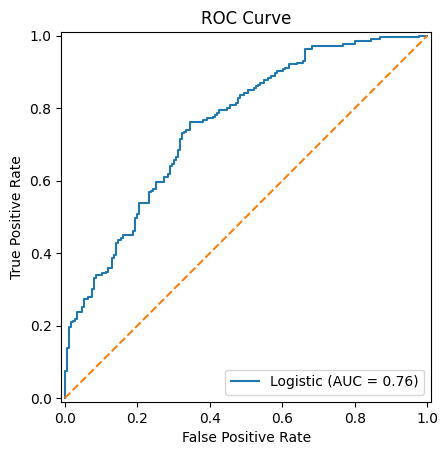

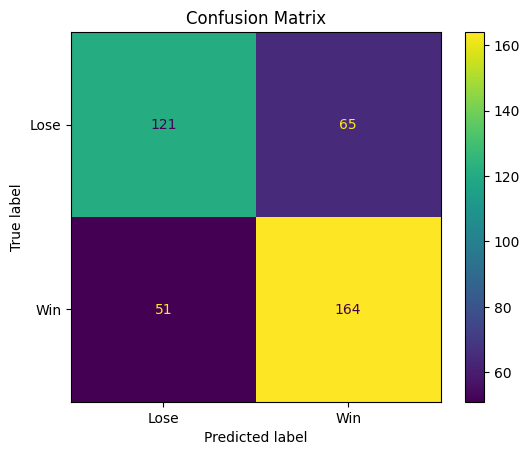

In [ ]:
plot_stats(y_test,pred,"Logistic",pred_prob)

In [ ]:
# Ridge Regression w/ cross validation

ridge_modelCV = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegressionCV(
        cv=5,
        penalty='l2',
        Cs=[0.001, 0.01, 0.1, 1, 10, 100],
        scoring='accuracy',
        max_iter=5000,
        n_jobs=-1
    ))
])

start_time = time.time()
best_threshold = threshold_tune(ridge_modelCV)
end_time = time.time()
pred_prob = ridge_modelCV.predict_proba(X_test)[:, 1]
pred = (pred_prob >= best_threshold).astype(int)

print(f'Training time: {end_time - start_time:.2f} seconds')
print("\nRidge Logistic Regression")
print("Chosen Threshold:", best_threshold)
print("Accuracy:", accuracy_score(y_test, pred))
print("Log Loss:", log_loss(y_test, pred_prob))
print("AUC:", roc_auc_score(y_test, pred_prob))

Best threshold: 0.49
Best validation accuracy: 0.6544622425629291
--------------------------------------------------
Training time: 0.86 seconds

Ridge Logistic Regression
Chosen Threshold: 0.49
Accuracy: 0.685785536159601
Log Loss: 0.5707756947373389
AUC: 0.7609152288072019


In [ ]:
best_C = ridge_modelCV.named_steps['clf'].C_[0]
print("Best C:", best_C)

Best C: 0.01


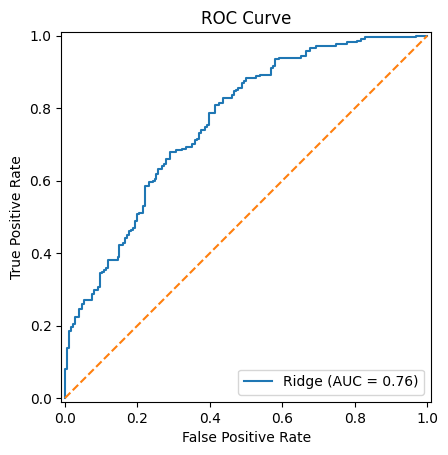

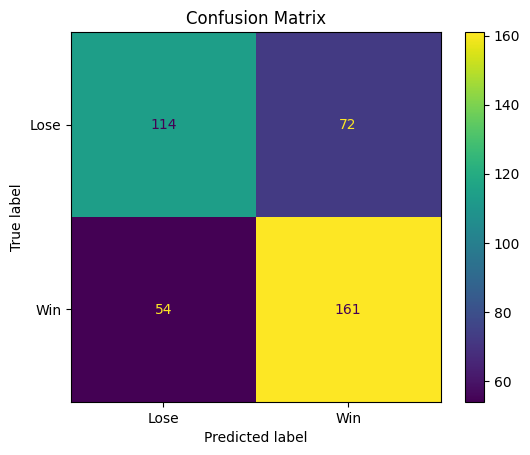

In [ ]:
plot_stats(y_test,pred,"Ridge",pred_prob)

In [ ]:
# Lasso Logistic Regression w/ cross validation
lasso_modelCV = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegressionCV(
        cv=5,
        penalty='l1',
        Cs=[0.001, 0.01, 0.1, 1, 10, 100],
        scoring='accuracy',
        max_iter=5000,
        n_jobs=-1,
        solver='liblinear'
    ))
])

start_time = time.time()
best_threshold = threshold_tune(lasso_modelCV)
end_time = time.time()
pred_prob = lasso_modelCV.predict_proba(X_test)[:, 1]
pred = (pred_prob >= best_threshold).astype(int)

print(f'Training time: {end_time - start_time:.2f} seconds')
print("\nLasso Logistic Regression")
print("Chosen Threshold:", best_threshold)
print("Accuracy:", accuracy_score(y_test, pred))
print("Log Loss:", log_loss(y_test, pred_prob))
print("AUC:", roc_auc_score(y_test, pred_prob))

Best threshold: 0.47000000000000003
Best validation accuracy: 0.6407322654462243
--------------------------------------------------
Training time: 7.50 seconds

Lasso Logistic Regression
Chosen Threshold: 0.47000000000000003
Accuracy: 0.7007481296758105
Log Loss: 0.5804301570066214
AUC: 0.7623905976494122


In [ ]:
best_C = lasso_modelCV.named_steps['clf'].C_[0]
print("Best C:", best_C)

Best C: 0.01


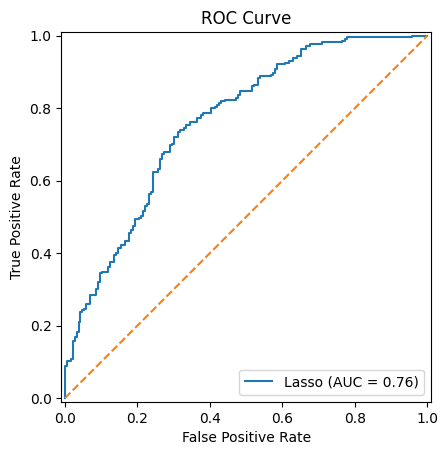

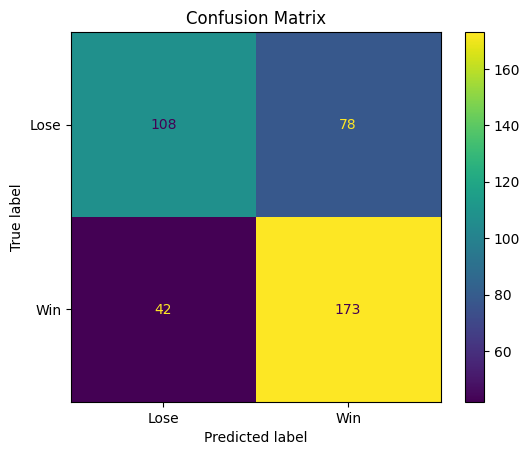

In [ ]:
plot_stats(y_test,pred,"Lasso",pred_prob)

In [ ]:
# Gradient Boosting w/ Grid Search

gb_model_grid = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', GradientBoostingClassifier(random_state=42))
])

params = {
          'clf__n_estimators': [100, 200],
          'clf__learning_rate':[0.01, 0.05, 0.1, 1],
          'clf__max_depth':[2, 3]
          }

gb_model = GridSearchCV(
    gb_model_grid,
    params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)


start_time = time.time()
best_threshold = threshold_tune(gb_model)
end_time = time.time()
pred_prob = gb_model.predict_proba(X_test)[:, 1]
pred = (pred_prob >= best_threshold).astype(int)

print(f'Training time: {end_time - start_time:.2f} seconds')
print("\nGradient Boosting w/ Grid Search")
print("Chosen Threshold:", best_threshold)
print("Accuracy:", accuracy_score(y_test, pred))
print("Log Loss:", log_loss(y_test, pred_prob))
print("AUC:", roc_auc_score(y_test, pred_prob))

Best threshold: 0.51
Best validation accuracy: 0.6384439359267735
--------------------------------------------------
Training time: 171.33 seconds

Gradient Boosting w/ Grid Search
Chosen Threshold: 0.51
Accuracy: 0.6907730673316709
Log Loss: 0.5743274816708336
AUC: 0.7553763440860215


In [ ]:
print("Best parameters:", gb_model.best_params_)

Best parameters: {'clf__learning_rate': 0.05, 'clf__max_depth': 2, 'clf__n_estimators': 100}


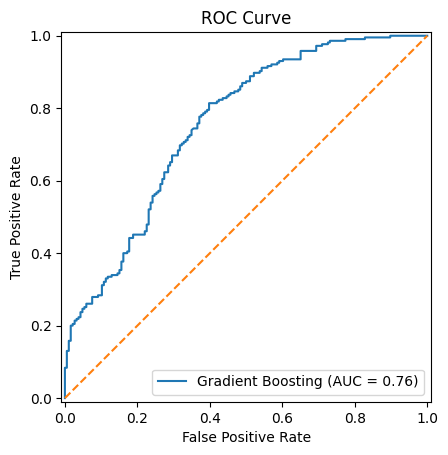

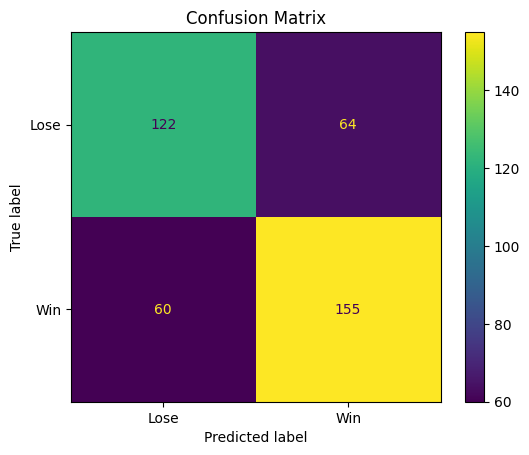

In [ ]:
plot_stats(y_test,pred,"Gradient Boosting",pred_prob)

In [ ]:
# Random Forest w/ Grid Search
rf_model_grid = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', RandomForestClassifier(random_state=42))
])

params = {
          'clf__n_estimators': [100, 200, 300],
          'clf__max_depth':[2, 4, 8],
          'clf__min_samples_leaf':[2, 3]
          }

rf_model = GridSearchCV(
    rf_model_grid,
    params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
start_time = time.time()
best_threshold = threshold_tune(rf_model)
end_time = time.time()
pred_prob = rf_model.predict_proba(X_test)[:, 1]
pred = (pred_prob >= best_threshold).astype(int)

print(f'Training time: {end_time - start_time:.2f} seconds')
print("\nRandom Forest")
print("Chosen Threshold:", best_threshold)
print("Accuracy:", accuracy_score(y_test, pred))
print("Log Loss:", log_loss(y_test, pred_prob))
print("AUC:", roc_auc_score(y_test, pred_prob))

Best threshold: 0.45
Best validation accuracy: 0.6430205949656751
--------------------------------------------------
Training time: 105.01 seconds

Random Forest
Chosen Threshold: 0.45
Accuracy: 0.6882793017456359
Log Loss: 0.5838985365530143
AUC: 0.7505376344086022


In [ ]:
print("Best parameters:", rf_model.best_params_)

Best parameters: {'clf__max_depth': 4, 'clf__min_samples_leaf': 2, 'clf__n_estimators': 300}


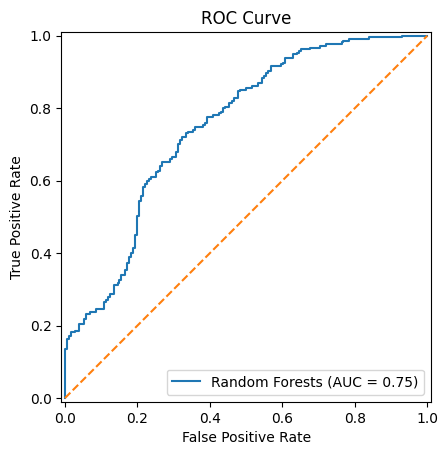

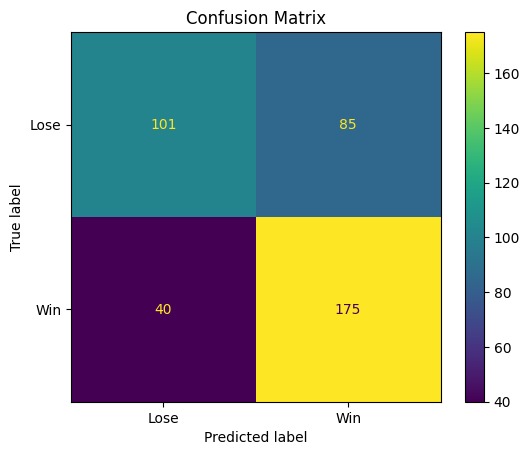

In [ ]:
plot_stats(y_test,pred,"Random Forests",pred_prob)

In [ ]:
from sklearn.base import ClassifierMixin, BaseEstimator
# Ensemble: GB + RF, averaged probabilities
class EnsembleModel(BaseEstimator, ClassifierMixin):
    def __init__(self, models):
        self.models = models
        self.classes_ = np.array([0, 1])

    def fit(self, X, y):
        for m in self.models:
            m.fit(X, y)
        return self

    def predict_proba(self, X):
        probs = np.mean([m.predict_proba(X)[:, 1] for m in self.models], axis=0)
        return np.column_stack([1 - probs, probs])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

ensemble_model = EnsembleModel([
    Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', GradientBoostingClassifier(n_estimators=200, learning_rate=0.01,
                                            max_depth=3, random_state=42))
    ]),
    Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', RandomForestClassifier(n_estimators=700, max_depth=5, min_samples_leaf=4,
                                        max_features='sqrt', random_state=42, n_jobs=-1))
    ])
])

start_time = time.time()
end_time = time.time()
ensemble_model.fit(X_train, y_train)
pred_prob = ensemble_model.predict_proba(X_test)[:, 1]
pred = (pred_prob >= 0.5).astype(int)

print(f'Training time: {end_time - start_time:.2f} seconds')
print("\nEnsemble (GB + RF, soft voting)")
print("Accuracy:", accuracy_score(y_test, pred))
print("Log Loss:", log_loss(y_test, pred_prob))
print("AUC:", roc_auc_score(y_test, pred_prob))

Training time: 0.00 seconds

Ensemble (GB + RF, soft voting)
Accuracy: 0.6982543640897756
Log Loss: 0.5792557970509937
AUC: 0.7537384346086522


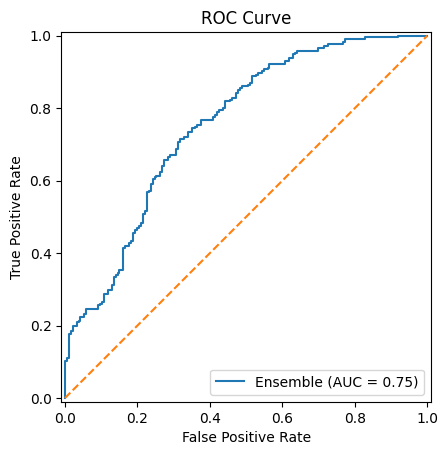

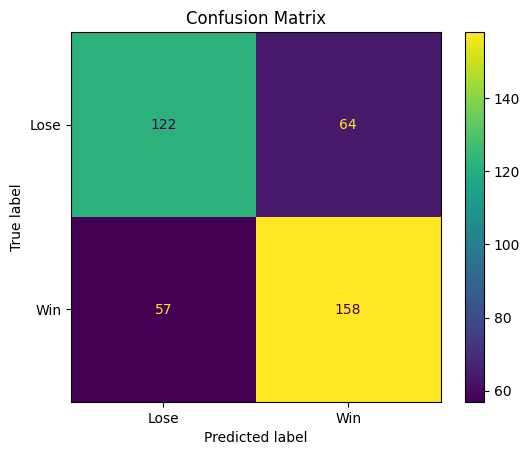

In [ ]:
plot_stats(y_test,pred,"Ensemble",pred_prob)

In [ ]:
# Baseline (chalk)
class ChalkModel(BaseEstimator, ClassifierMixin):

    def fit(self, X, y=None):
        self.classes_ = np.array([0, 1])
        return self

    def predict_proba(self, X):
        # SeedDiff = T1_SeedNum - T2_SeedNum; lower seed number = better team
        if hasattr(X, 'columns'):
            seed_diff = X['SeedDiff'].values
        else:
            seed_diff = np.asarray(X)[:, 0]
        prob_t1 = np.where(seed_diff < 0, 1.0,
                  np.where(seed_diff > 0, 0.0, 0.5))
        return np.column_stack([1 - prob_t1, prob_t1])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

# Chalk baseline metrics
chalk = ChalkModel().fit(X_train, y_train)
pred_prob = chalk.predict_proba(X_test)[:, 1]
pred = (pred_prob >= 0.5).astype(int)
print("Chalk baseline (always pick lower seed)")
print("Accuracy:", accuracy_score(y_test, pred))
print("Correct:", int((pred == y_test).sum()), "/", len(y_test))
print()

Chalk baseline (always pick lower seed)
Accuracy: 0.6957605985037406
Correct: 279 / 401



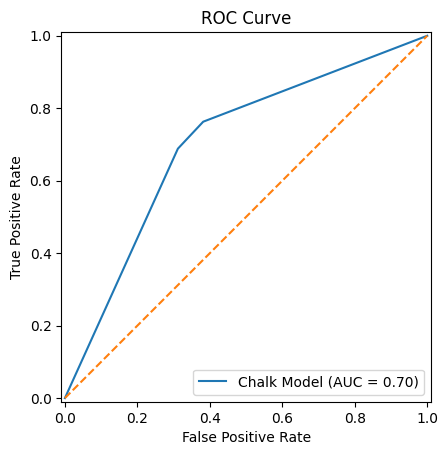

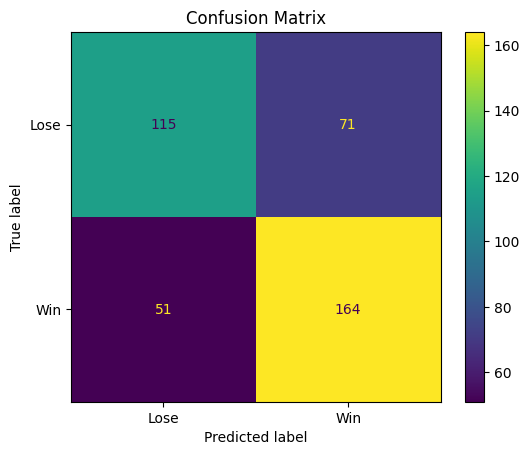

In [ ]:
plot_stats(y_test, pred, "Chalk Model", pred_prob)

In [ ]:
team_feature_lookup = season_features.set_index(['Season', 'TeamID'])

def make_matchup_row(season, team1, team2):
    row = {'Season': season, 'Team1': min(team1, team2), 'Team2': max(team1, team2)}
    actual_team1 = row['Team1']
    actual_team2 = row['Team2']
    t1 = team_feature_lookup.loc[(season, actual_team1)]
    t2 = team_feature_lookup.loc[(season, actual_team2)]
    out = {'Season': season, 'Team1': actual_team1, 'Team2': actual_team2}

    for feat in base_feature_names:
        if feat in t1.index and feat in t2.index:
            out[f'T1_{feat}'] = t1[feat]
            out[f'T2_{feat}'] = t2[feat]
            out[f'DIFF_{feat}'] = t1[feat] - t2[feat]

    out['SeedDiff'] = out['T1_SeedNum'] - out['T2_SeedNum']
    out['T1_Off_vs_T2_Def'] = out['T1_OffRtg'] - out['T2_DefRtg']
    out['T2_Off_vs_T1_Def'] = out['T2_OffRtg'] - out['T1_DefRtg']
    out['NetMatchupEdge'] = out['T1_Off_vs_T2_Def'] - out['T2_Off_vs_T1_Def']

    return pd.DataFrame([out])

def predict_team1_win_prob(model, season, team1, team2):
    matchup = make_matchup_row(season, team1, team2)
    matchup = matchup.reindex(columns=feature_cols, fill_value=np.nan)
    prob = model.predict_proba(matchup)[0, 1]
    return prob

**Simulator**

In [ ]:
def make_model(model_name: str):
    """
    Return a fresh sklearn pipeline for the chosen model. Use best paramters from
    grid search for models that used it and performed better.
    """
    model_name = model_name.lower()

    if model_name in ("ridge"):
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", LogisticRegressionCV(
                cv=5,
                penalty="l2",
                Cs=[0.001, 0.01, 0.1, 1, 10, 100],
                scoring="roc_auc",
                max_iter=5000,
                n_jobs=-1
            ))
        ])

    elif model_name == "lasso":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", LogisticRegressionCV(
                cv=5,
                penalty="l1",
                Cs=[0.001, 0.01, 0.1, 1, 10, 100],
                scoring="roc_auc",
                max_iter=5000,
                n_jobs=-1,
                solver="liblinear"
            ))
        ])

    elif model_name == "logistic":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                penalty=None,
                max_iter=5000,
                n_jobs=-1,
            ))
        ])

    elif model_name == "gb":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", GradientBoostingClassifier(
                n_estimators=200,
                learning_rate=0.01,
                max_depth=3,
                random_state=42
            ))
        ])

    elif model_name == "rf":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", RandomForestClassifier(
                n_estimators=300,
                max_depth=8,
                min_samples_leaf=3,
                max_features="sqrt",
                random_state=42,
                n_jobs=-1
            ))
        ])

    elif model_name == "ensemble":
        # Ensemble of logistic + GB + RF
        return EnsembleModel([
            #make_model("logistic"),
            make_model("gb"),
            make_model("rf")
        ])

    elif model_name == "chalk":
        # Seed-based baseline
        return ChalkModel()

    else:
        raise ValueError(
            f"Unknown model_name='{model_name}'. "
            f"Use 'logistic', 'ridge', 'lasso', 'gb', 'rf', 'ensemble', or 'chalk'."
        )

# Trains on seasons before target year. Optionally augments the
# training set with regular-season matchups from those same prior years.
def train_model_for_year(target_year: int, model_name: str,
                          augment_with_regular_season: bool = False,
                          regular_season_weight: float = 0.05):
    """
    Train a model on all tournament matchups from seasons strictly
    before `target_year`.

    When `augment_with_regular_season` is True, we additionally include
    regular-season matchups from those same prior seasons in the
    training set, weighted by `regular_season_weight` (default 0.05)
    relative to tournament rows (weight 1.0). The default weight gives
    roughly equal *total* weight to tournament and regular-season data
    (since there are ~90x more regular-season games than tournament
    games), so the model still strongly learns tournament-specific
    patterns while gaining the broader regular-season signal.

    Notes:
      - We never use regular-season data from the target year or later
        (no leakage from the test season).
      - Models that don't accept sample_weight (chalk) ignore the weight
        argument; this is fine since chalk doesn't actually train.
    """
    tourney_train = model_df[model_df["Season"] < target_year].copy()
    if tourney_train.empty:
        raise ValueError(f"No training data available before {target_year}.")

    if augment_with_regular_season:
        # Only past seasons -- never the target year or later
        reg_train = reg_model_df[reg_model_df["Season"] < target_year].copy()

        X_tourney = tourney_train[feature_cols].copy()
        X_reg = reg_train[feature_cols].copy()
        y_tourney = tourney_train["Team1Win"].copy()
        y_reg = reg_train["Team1Win"].copy()

        X_train = pd.concat([X_tourney, X_reg], ignore_index=True)
        y_train = pd.concat([y_tourney, y_reg], ignore_index=True)
        # Tournament rows weight 1.0, regular-season rows weight w
        sample_weight = np.concatenate([
            np.ones(len(X_tourney)),
            np.full(len(X_reg), regular_season_weight)
        ])

        model = make_model(model_name)
        # Try to pass sample_weight; not all estimators support it
        # (notably ChalkModel doesn't, but it doesn't actually fit anyway)
        try:
            model.fit(X_train, y_train, clf__sample_weight=sample_weight)
        except (TypeError, ValueError):
            model.fit(X_train, y_train)
    else:
        X_train = tourney_train[feature_cols].copy()
        y_train = tourney_train["Team1Win"].copy()
        model = make_model(model_name)
        model.fit(X_train, y_train)

    return model

team_name_map = teams.set_index("TeamID")["TeamName"].to_dict()

def get_team_name(team_id):
    return team_name_map.get(team_id, f"TeamID_{team_id}")

team_name_map = teams.set_index("TeamID")["TeamName"].to_dict()

def get_team_name(team_id):
    return team_name_map.get(team_id, f"TeamID_{team_id}")




In [ ]:
# Builds a single row df of features of both teams
def build_matchup_features(season: int, team_a: int, team_b: int):
    team1 = min(team_a, team_b)
    team2 = max(team_a, team_b)

    if (season, team1) not in team_feature_lookup.index:
        raise KeyError(f"Missing season_features for season={season}, team={team1}")
    if (season, team2) not in team_feature_lookup.index:
        raise KeyError(f"Missing season_features for season={season}, team={team2}")

    t1 = team_feature_lookup.loc[(season, team1)]
    t2 = team_feature_lookup.loc[(season, team2)]

    row = {
        "Season": season,
        "Team1": team1,
        "Team2": team2
    }

    for feat in base_feature_names:
        if feat in t1.index and feat in t2.index:
            row[f"T1_{feat}"] = t1[feat]
            row[f"T2_{feat}"] = t2[feat]
            row[f"DIFF_{feat}"] = t1[feat] - t2[feat]

    # Core interaction features used earlier
    row["SeedDiff"] = row.get("T1_SeedNum", np.nan) - row.get("T2_SeedNum", np.nan)
    row["T1_Off_vs_T2_Def"] = row.get("T1_OffRtg", np.nan) - row.get("T2_DefRtg", np.nan)
    row["T2_Off_vs_T1_Def"] = row.get("T2_OffRtg", np.nan) - row.get("T1_DefRtg", np.nan)
    row["NetMatchupEdge"] = row["T1_Off_vs_T2_Def"] - row["T2_Off_vs_T1_Def"]
    row["ReboundEdge"] = row.get("T1_ORR", np.nan) - row.get("T2_DRR", np.nan)
    row["BallSecurityEdge"] = row.get("T1_Ast_TO", np.nan) - row.get("T2_Ast_TO", np.nan)
    matchup = pd.DataFrame([row])

    # Guarantee all required columns exist
    for col in feature_cols:
        if col not in matchup.columns:
            matchup[col] = np.nan

    matchup = matchup[feature_cols]
    return matchup, team1, team2

In [ ]:
# Predict winner of team A vs team B
def predict_matchup(model, season: int, team_a: int, team_b: int):

    # Handles the Team1 = min(id), Team2 = max(id) convention used in training.
    matchup, team1, team2 = build_matchup_features(season, team_a, team_b)
    prob_team1_wins = model.predict_proba(matchup)[0, 1]

    if team_a == team1:
        prob_a = prob_team1_wins
        prob_b = 1 - prob_team1_wins
    else:
        prob_a = 1 - prob_team1_wins
        prob_b = prob_team1_wins

    predicted_winner = team_a if prob_a >= prob_b else team_b
    predicted_prob = max(prob_a, prob_b)

    return {
        "team_a": team_a,
        "team_b": team_b,
        "prob_team_a": prob_a,
        "prob_team_b": prob_b,
        "predicted_winner": predicted_winner,
        "predicted_winner_prob": predicted_prob
    }

In [ ]:
# Gets round number (round of 64 = 1, etc)
def get_round_num_from_slot(slot_name: str):
    m = re.match(r"R(\d+)", str(slot_name))
    if m:
        return int(m.group(1))
    return None

# Uses ESPN bracket challenge scoring
def espn_points_for_round(round_num: int):
    points_map = {
        1: 10,
        2: 20,
        3: 40,
        4: 80,
        5: 160,
        6: 320
    }
    return points_map.get(round_num, 0)

In [ ]:
# Finds all actual winners
def build_actual_game_winner_lookup(season: int):
    df = tourney_compact[tourney_compact["Season"] == season].copy()
    lookup = {}
    for _, r in df.iterrows():
        pair = frozenset([r["WTeamID"], r["LTeamID"]])
        lookup[pair] = r["WTeamID"]

    return lookup

In [ ]:
# Maps seed to team ID
def get_seed_to_team_map(season: int):
    season_seeds = seeds[seeds["Season"] == season].copy()
    if season_seeds.empty:
        raise ValueError(f"No seeds found for season {season}")

    return dict(zip(season_seeds["Seed"], season_seeds["TeamID"]))

In [ ]:
# Predicted winners
def simulate_predicted_bracket(season: int, model):
    season_slots = slots[slots["Season"] == season].copy()
    if season_slots.empty:
        raise ValueError(f"No slot data found for season {season}")

    # Initial resolved labels are seeds
    resolved = get_seed_to_team_map(season).copy()
    results = []
    unresolved = season_slots.copy()

    # Keep resolving until no slots remain or no progress
    while not unresolved.empty:
        progress = False
        remaining_rows = []

        for _, row in unresolved.iterrows():
            slot = row["Slot"]
            strong_label = row["StrongSeed"]
            weak_label = row["WeakSeed"]

            if strong_label in resolved and weak_label in resolved:
                strong_team = resolved[strong_label]
                weak_team = resolved[weak_label]

                pred = predict_matchup(model, season, strong_team, weak_team)
                winner = pred["predicted_winner"]

                resolved[slot] = winner

                round_num = get_round_num_from_slot(slot)
                points = espn_points_for_round(round_num)

                results.append({
                    "Season": season,
                    "Slot": slot,
                    "Round": round_num,
                    "PossiblePoints": points,
                    "StrongLabel": strong_label,
                    "WeakLabel": weak_label,
                    "StrongTeamID": strong_team,
                    "WeakTeamID": weak_team,
                    "StrongTeamName": get_team_name(strong_team),
                    "WeakTeamName": get_team_name(weak_team),
                    "PredWinnerID": winner,
                    "PredWinnerName": get_team_name(winner),
                    "PredWinnerProb": pred["predicted_winner_prob"]
                })
                progress = True
            else:
                remaining_rows.append(row)

        if not progress:
            raise RuntimeError(
                f"Could not resolve all slots for season {season}. "
                f"Remaining slots:\n{pd.DataFrame(remaining_rows)}"
            )

        unresolved = pd.DataFrame(remaining_rows)

    bracket_df = pd.DataFrame(results)

    if not bracket_df.empty:
        bracket_df = bracket_df.sort_values(["Round", "Slot"]).reset_index(drop=True)

    return bracket_df, resolved

In [ ]:
# Actual winners
def simulate_actual_bracket(season: int):

    # Builds a column of actual winners
    season_slots = slots[slots["Season"] == season].copy()

    if season_slots.empty:
        raise ValueError(f"No slot data found for season {season}")

    actual_lookup = build_actual_game_winner_lookup(season)

    resolved = get_seed_to_team_map(season).copy()

    results = []
    unresolved = season_slots.copy()

    while not unresolved.empty:
        progress = False
        remaining_rows = []

        for _, row in unresolved.iterrows():
            slot = row["Slot"]
            strong_label = row["StrongSeed"]
            weak_label = row["WeakSeed"]

            if strong_label in resolved and weak_label in resolved:
                strong_team = resolved[strong_label]
                weak_team = resolved[weak_label]

                pair = frozenset([strong_team, weak_team])
                if pair not in actual_lookup:
                    raise KeyError(
                        f"Could not find actual tournament result for season={season}, "
                        f"teams=({strong_team}, {weak_team}) in slot {slot}"
                    )

                winner = actual_lookup[pair]
                resolved[slot] = winner

                round_num = get_round_num_from_slot(slot)
                points = espn_points_for_round(round_num)

                results.append({
                    "Season": season,
                    "Slot": slot,
                    "Round": round_num,
                    "PossiblePoints": points,
                    "StrongLabel": strong_label,
                    "WeakLabel": weak_label,
                    "StrongTeamID": strong_team,
                    "WeakTeamID": weak_team,
                    "StrongTeamName": get_team_name(strong_team),
                    "WeakTeamName": get_team_name(weak_team),
                    "ActualWinnerID": winner,
                    "ActualWinnerName": get_team_name(winner)
                })
                progress = True
            else:
                remaining_rows.append(row)

        if not progress:
            raise RuntimeError(
                f"Could not resolve all actual slots for season {season}. "
                f"Remaining slots:\n{pd.DataFrame(remaining_rows)}"
            )

        unresolved = pd.DataFrame(remaining_rows)

    actual_df = pd.DataFrame(results)

    if not actual_df.empty:
        actual_df = actual_df.sort_values(["Round", "Slot"]).reset_index(drop=True)

    return actual_df, resolved

In [ ]:
# Compute ESPN score and total correct picks
def score_bracket(pred_df: pd.DataFrame, actual_df: pd.DataFrame):
    merged = pred_df.merge(
        actual_df[["Slot", "ActualWinnerID", "ActualWinnerName"]],
        on="Slot",
        how="inner"
    )

    merged["CorrectPick"] = (merged["PredWinnerID"] == merged["ActualWinnerID"]).astype(int)
    merged["EarnedPoints"] = merged["CorrectPick"] * merged["PossiblePoints"]
    total_score = int(merged["EarnedPoints"].sum())
    max_score = int(merged["PossiblePoints"].sum())
    round_summary = (merged.groupby("Round", dropna=False).agg(
        Games=("Slot", "count"),
        Correct=("CorrectPick", "sum"),
        PossiblePoints=("PossiblePoints", "sum"),
        EarnedPoints=("EarnedPoints", "sum")
      ).reset_index().sort_values("Round"))
    return merged, total_score, max_score, round_summary

In [ ]:
# Trains on only previous seasons data, never future
def run_bracket_experiment(year: int, model_name: str = "logistic",
                            show_round_summary: bool = True,
                            augment_with_regular_season: bool = False,
                            regular_season_weight: float = 0.05):
    aug_msg = " + regular-season augmentation" if augment_with_regular_season else ""
    print(f"Training model '{model_name}'{aug_msg} on seasons before {year}...")
    model = train_model_for_year(
        year, model_name=model_name,
        augment_with_regular_season=augment_with_regular_season,
        regular_season_weight=regular_season_weight
    )

    print(f"Simulating predicted bracket for {year}...")
    pred_df, _ = simulate_predicted_bracket(year, model)

    print(f"Reconstructing actual bracket for {year}...")
    actual_df, _ = simulate_actual_bracket(year)

    scored_df, total_score, max_score, round_summary = score_bracket(pred_df, actual_df)

    print(f"\n{year} | Model: {model_name}")
    print(f"Total ESPN Score: {total_score} / {max_score}")
    print(f"Correct Picks: {scored_df['CorrectPick'].sum()} / {len(scored_df)}")

    if show_round_summary:
        print("\nRound-by-round summary:")
        display(round_summary)

    return {
        "model": model,
        "predicted_bracket": pred_df,
        "actual_bracket": actual_df,
        "scored_bracket": scored_df,
        "round_summary": round_summary,
        "total_score": total_score,
        "max_score": max_score
    }

In [ ]:
# Compare any models
def compare_models_for_year(year: int, model_names=("chalk", "ridge", "lasso", "gb", "rf", "ensemble")):
    summaries = []
    outputs = {}

    for model_name in model_names:
        out = run_bracket_experiment(year, model_name=model_name, show_round_summary=False)
        outputs[model_name] = out

        summaries.append({
            "Year": year,
            "Model": model_name,
            "TotalScore": out["total_score"],
            "MaxScore": out["max_score"],
            "CorrectPicks": int(out["scored_bracket"]["CorrectPick"].sum()),
            "Games": int(len(out["scored_bracket"]))
        })

    summary_df = pd.DataFrame(summaries).sort_values("TotalScore", ascending=False).reset_index(drop=True)

    print(f"\nComparison for {year}:")
    display(summary_df)

    return summary_df, outputs

**Results**

In [ ]:
result_log = run_bracket_experiment(2016, model_name="logistic")

Training model 'logistic' on seasons before 2016...
Simulating predicted bracket for 2016...
Reconstructing actual bracket for 2016...

2016 | Model: logistic
Total ESPN Score: 580 / 1920
Correct Picks: 40 / 67

Round-by-round summary:


,Round,Games,Correct,PossiblePoints,EarnedPoints
0,1.0,32,22,320,220
1,2.0,16,12,320,240
2,3.0,8,3,320,120
3,4.0,4,0,320,0
4,5.0,2,0,320,0
5,6.0,1,0,320,0
6,NaN,4,3,0,0


In [ ]:
result_ridge = run_bracket_experiment(2017, model_name="ridge")

Training model 'ridge' on seasons before 2017...
Simulating predicted bracket for 2017...
Reconstructing actual bracket for 2017...

2017 | Model: ridge
Total ESPN Score: 610 / 1920
Correct Picks: 41 / 67

Round-by-round summary:


,Round,Games,Correct,PossiblePoints,EarnedPoints
0,1.0,32,27,320,270
1,2.0,16,9,320,180
2,3.0,8,4,320,160
3,4.0,4,0,320,0
4,5.0,2,0,320,0
5,6.0,1,0,320,0
6,NaN,4,1,0,0


In [ ]:
result_lasso = run_bracket_experiment(2017, model_name="lasso")

Training model 'lasso' on seasons before 2017...
Simulating predicted bracket for 2017...
Reconstructing actual bracket for 2017...

2017 | Model: lasso
Total ESPN Score: 1060 / 1920
Correct Picks: 43 / 67

Round-by-round summary:


,Round,Games,Correct,PossiblePoints,EarnedPoints
0,1.0,32,26,320,260
1,2.0,16,8,320,160
2,3.0,8,4,320,160
3,4.0,4,2,320,160
4,5.0,2,2,320,320
5,6.0,1,0,320,0
6,NaN,4,1,0,0


In [ ]:
result_gb = run_bracket_experiment(2009, model_name="gb")

Training model 'gb' on seasons before 2009...
Simulating predicted bracket for 2009...
Reconstructing actual bracket for 2009...

2009 | Model: gb
Total ESPN Score: 1300 / 1920
Correct Picks: 45 / 64

Round-by-round summary:


,Round,Games,Correct,PossiblePoints,EarnedPoints
0,1.0,32,24,320,240
1,2.0,16,11,320,220
2,3.0,8,5,320,200
3,4.0,4,2,320,160
4,5.0,2,1,320,160
5,6.0,1,1,320,320
6,NaN,1,1,0,0


In [ ]:
result_rf = run_bracket_experiment(2017, model_name="rf")

Training model 'rf' on seasons before 2017...
Simulating predicted bracket for 2017...
Reconstructing actual bracket for 2017...

2017 | Model: rf
Total ESPN Score: 1150 / 1920
Correct Picks: 45 / 67

Round-by-round summary:


,Round,Games,Correct,PossiblePoints,EarnedPoints
0,1.0,32,27,320,270
1,2.0,16,10,320,200
2,3.0,8,3,320,120
3,4.0,4,1,320,80
4,5.0,2,1,320,160
5,6.0,1,1,320,320
6,NaN,4,2,0,0


In [ ]:
result_ensemble = run_bracket_experiment(2017, model_name="ensemble")

Training model 'ensemble' on seasons before 2017...
Simulating predicted bracket for 2017...
Reconstructing actual bracket for 2017...

2017 | Model: ensemble
Total ESPN Score: 1160 / 1920
Correct Picks: 45 / 67

Round-by-round summary:


,Round,Games,Correct,PossiblePoints,EarnedPoints
0,1.0,32,26,320,260
1,2.0,16,11,320,220
2,3.0,8,3,320,120
3,4.0,4,1,320,80
4,5.0,2,1,320,160
5,6.0,1,1,320,320
6,NaN,4,2,0,0


In [ ]:
result_chalk = run_bracket_experiment(2017, model_name="chalk")

Training model 'chalk' on seasons before 2017...
Simulating predicted bracket for 2017...
Reconstructing actual bracket for 2017...

2017 | Model: chalk
Total ESPN Score: 820 / 1920
Correct Picks: 46 / 67

Round-by-round summary:


,Round,Games,Correct,PossiblePoints,EarnedPoints
0,1.0,32,26,320,260
1,2.0,16,12,320,240
2,3.0,8,4,320,160
3,4.0,4,2,320,160
4,5.0,2,0,320,0
5,6.0,1,0,320,0
6,NaN,4,2,0,0


In [ ]:
comparison, outputs = compare_models_for_year(2025, model_names=("chalk", "logistic", "ridge", "lasso", "gb", "rf", "ensemble"))

Training model 'chalk' on seasons before 2025...
Simulating predicted bracket for 2025...
Reconstructing actual bracket for 2025...

2025 | Model: chalk
Total ESPN Score: 1090 / 1920
Correct Picks: 50 / 67
Training model 'logistic' on seasons before 2025...
Simulating predicted bracket for 2025...
Reconstructing actual bracket for 2025...

2025 | Model: logistic
Total ESPN Score: 1160 / 1920
Correct Picks: 46 / 67
Training model 'ridge' on seasons before 2025...
Simulating predicted bracket for 2025...
Reconstructing actual bracket for 2025...

2025 | Model: ridge
Total ESPN Score: 1080 / 1920
Correct Picks: 48 / 67
Training model 'lasso' on seasons before 2025...
Simulating predicted bracket for 2025...
Reconstructing actual bracket for 2025...

2025 | Model: lasso
Total ESPN Score: 1080 / 1920
Correct Picks: 48 / 67
Training model 'gb' on seasons before 2025...
Simulating predicted bracket for 2025...
Reconstructing actual bracket for 2025...

2025 | Model: gb
Total ESPN Score: 1050 

,Year,Model,TotalScore,MaxScore,CorrectPicks,Games
0,2025,logistic,1160,1920,46,67
1,2025,rf,1140,1920,52,67
2,2025,ensemble,1130,1920,53,67
3,2025,chalk,1090,1920,50,67
4,2025,ridge,1080,1920,48,67
5,2025,lasso,1080,1920,48,67
6,2025,gb,1050,1920,51,67


In [ ]:
comparison, outputs = compare_models_for_year(2025, model_names=("chalk", "logistic", "ridge", "lasso", "gb", "rf", "ensemble"))
display(comparison)

Training model 'chalk' on seasons before 2025...
Simulating predicted bracket for 2025...
Reconstructing actual bracket for 2025...

2025 | Model: chalk
Total ESPN Score: 1090 / 1920
Correct Picks: 50 / 67
Training model 'logistic' on seasons before 2025...
Simulating predicted bracket for 2025...
Reconstructing actual bracket for 2025...

2025 | Model: logistic
Total ESPN Score: 1160 / 1920
Correct Picks: 46 / 67
Training model 'ridge' on seasons before 2025...
Simulating predicted bracket for 2025...
Reconstructing actual bracket for 2025...

2025 | Model: ridge
Total ESPN Score: 1080 / 1920
Correct Picks: 48 / 67
Training model 'lasso' on seasons before 2025...
Simulating predicted bracket for 2025...
Reconstructing actual bracket for 2025...

2025 | Model: lasso
Total ESPN Score: 1080 / 1920
Correct Picks: 48 / 67
Training model 'gb' on seasons before 2025...
Simulating predicted bracket for 2025...
Reconstructing actual bracket for 2025...

2025 | Model: gb
Total ESPN Score: 1050 

,Year,Model,TotalScore,MaxScore,CorrectPicks,Games
0,2025,logistic,1160,1920,46,67
1,2025,rf,1140,1920,52,67
2,2025,ensemble,1130,1920,53,67
3,2025,chalk,1090,1920,50,67
4,2025,ridge,1080,1920,48,67
5,2025,lasso,1080,1920,48,67
6,2025,gb,1050,1920,51,67


,Year,Model,TotalScore,MaxScore,CorrectPicks,Games
0,2025,logistic,1160,1920,46,67
1,2025,rf,1140,1920,52,67
2,2025,ensemble,1130,1920,53,67
3,2025,chalk,1090,1920,50,67
4,2025,ridge,1080,1920,48,67
5,2025,lasso,1080,1920,48,67
6,2025,gb,1050,1920,51,67


In [ ]:
display(result_log["scored_bracket"][
    ["Slot", "Round", "StrongTeamName", "WeakTeamName", "PredWinnerName", "ActualWinnerName", "CorrectPick", "EarnedPoints"]])

,Slot,Round,StrongTeamName,WeakTeamName,PredWinnerName,ActualWinnerName,CorrectPick,EarnedPoints
0,R1W1,1.0,North Carolina,FGCU,North Carolina,North Carolina,1,10
1,R1W2,1.0,Xavier,Weber St,Xavier,Xavier,1,10
2,R1W3,1.0,West Virginia,SF Austin,West Virginia,SF Austin,0,0
3,R1W4,1.0,Kentucky,Stony Brook,Kentucky,Kentucky,1,10
4,R1W5,1.0,Indiana,Chattanooga,Indiana,Indiana,1,10
...,...,...,...,...,...,...,...,...
62,R6CH,6.0,Indiana,Kansas,Indiana,Villanova,0,0
63,W11,NaN,Michigan,Tulsa,Michigan,Michigan,1,0
64,W16,NaN,F Dickinson,FGCU,FGCU,FGCU,1,0
65,Y11,NaN,Vanderbilt,Wichita St,Wichita St,Wichita St,1,0


In [ ]:
display(result_ridge["scored_bracket"][
    ["Slot", "Round", "StrongTeamName", "WeakTeamName", "PredWinnerName", "ActualWinnerName", "CorrectPick", "EarnedPoints"]])

,Slot,Round,StrongTeamName,WeakTeamName,PredWinnerName,ActualWinnerName,CorrectPick,EarnedPoints
0,R1W1,1.0,Villanova,New Orleans,Villanova,Villanova,1,10
1,R1W2,1.0,Duke,Troy,Duke,Duke,1,10
2,R1W3,1.0,Baylor,New Mexico St,Baylor,Baylor,1,10
3,R1W4,1.0,Florida,ETSU,Florida,Florida,1,10
4,R1W5,1.0,Virginia,UNC Wilmington,Virginia,Virginia,1,10
...,...,...,...,...,...,...,...,...
62,R6CH,6.0,Duke,Kentucky,Kentucky,North Carolina,0,0
63,W11,NaN,Providence,USC,USC,USC,1,0
64,W16,NaN,Mt St Mary's,New Orleans,New Orleans,Mt St Mary's,0,0
65,Y16,NaN,NC Central,UC Davis,NC Central,UC Davis,0,0


In [ ]:
display(result_lasso["scored_bracket"][
    ["Slot", "Round", "StrongTeamName", "WeakTeamName", "PredWinnerName", "ActualWinnerName", "CorrectPick", "EarnedPoints"]])

,Slot,Round,StrongTeamName,WeakTeamName,PredWinnerName,ActualWinnerName,CorrectPick,EarnedPoints
0,R1W1,1.0,Villanova,New Orleans,Villanova,Villanova,1,10
1,R1W2,1.0,Duke,Troy,Duke,Duke,1,10
2,R1W3,1.0,Baylor,New Mexico St,Baylor,Baylor,1,10
3,R1W4,1.0,Florida,ETSU,Florida,Florida,1,10
4,R1W5,1.0,Virginia,UNC Wilmington,Virginia,Virginia,1,10
...,...,...,...,...,...,...,...,...
62,R6CH,6.0,Gonzaga,North Carolina,Gonzaga,North Carolina,0,0
63,W11,NaN,Providence,USC,USC,USC,1,0
64,W16,NaN,Mt St Mary's,New Orleans,New Orleans,Mt St Mary's,0,0
65,Y16,NaN,NC Central,UC Davis,NC Central,UC Davis,0,0


In [ ]:
display(result_gb["scored_bracket"][
    ["Slot", "Round", "StrongTeamName", "WeakTeamName", "PredWinnerName", "ActualWinnerName", "CorrectPick", "EarnedPoints"]])

,Slot,Round,StrongTeamName,WeakTeamName,PredWinnerName,ActualWinnerName,CorrectPick,EarnedPoints
0,R1W1,1.0,Pittsburgh,ETSU,Pittsburgh,Pittsburgh,1,10
1,R1W2,1.0,Duke,Binghamton,Duke,Duke,1,10
2,R1W3,1.0,Villanova,American Univ,Villanova,Villanova,1,10
3,R1W4,1.0,Xavier,Portland St,Xavier,Xavier,1,10
4,R1W5,1.0,Florida St,Wisconsin,Wisconsin,Wisconsin,1,10
...,...,...,...,...,...,...,...,...
59,R4Z1,4.0,Connecticut,Memphis,Connecticut,Connecticut,1,80
60,R5WX,5.0,Pittsburgh,North Carolina,North Carolina,North Carolina,1,160
61,R5YZ,5.0,Kansas,Connecticut,Connecticut,Michigan St,0,0
62,R6CH,6.0,North Carolina,Connecticut,North Carolina,North Carolina,1,320


In [ ]:
display(result_rf["scored_bracket"][
    ["Slot", "Round", "StrongTeamName", "WeakTeamName", "PredWinnerName", "ActualWinnerName", "CorrectPick", "EarnedPoints"]])

,Slot,Round,StrongTeamName,WeakTeamName,PredWinnerName,ActualWinnerName,CorrectPick,EarnedPoints
0,R1W1,1.0,Villanova,Mt St Mary's,Villanova,Villanova,1,10
1,R1W2,1.0,Duke,Troy,Duke,Duke,1,10
2,R1W3,1.0,Baylor,New Mexico St,Baylor,Baylor,1,10
3,R1W4,1.0,Florida,ETSU,Florida,Florida,1,10
4,R1W5,1.0,Virginia,UNC Wilmington,Virginia,Virginia,1,10
...,...,...,...,...,...,...,...,...
62,R6CH,6.0,Villanova,North Carolina,North Carolina,North Carolina,1,320
63,W11,NaN,Providence,USC,USC,USC,1,0
64,W16,NaN,Mt St Mary's,New Orleans,Mt St Mary's,Mt St Mary's,1,0
65,Y16,NaN,NC Central,UC Davis,NC Central,UC Davis,0,0


In [ ]:
display(result_ensemble["scored_bracket"][
    ["Slot", "Round", "StrongTeamName", "WeakTeamName", "PredWinnerName", "ActualWinnerName", "CorrectPick", "EarnedPoints"]])

,Slot,Round,StrongTeamName,WeakTeamName,PredWinnerName,ActualWinnerName,CorrectPick,EarnedPoints
0,R1W1,1.0,Villanova,Mt St Mary's,Villanova,Villanova,1,10
1,R1W2,1.0,Duke,Troy,Duke,Duke,1,10
2,R1W3,1.0,Baylor,New Mexico St,Baylor,Baylor,1,10
3,R1W4,1.0,Florida,ETSU,Florida,Florida,1,10
4,R1W5,1.0,Virginia,UNC Wilmington,Virginia,Virginia,1,10
...,...,...,...,...,...,...,...,...
62,R6CH,6.0,Villanova,North Carolina,North Carolina,North Carolina,1,320
63,W11,NaN,Providence,USC,USC,USC,1,0
64,W16,NaN,Mt St Mary's,New Orleans,Mt St Mary's,Mt St Mary's,1,0
65,Y16,NaN,NC Central,UC Davis,NC Central,UC Davis,0,0


In [ ]:
display(result_chalk["scored_bracket"][
    ["Slot", "Round", "StrongTeamName", "WeakTeamName", "PredWinnerName", "ActualWinnerName", "CorrectPick", "EarnedPoints"]])

,Slot,Round,StrongTeamName,WeakTeamName,PredWinnerName,ActualWinnerName,CorrectPick,EarnedPoints
0,R1W1,1.0,Villanova,Mt St Mary's,Villanova,Villanova,1,10
1,R1W2,1.0,Duke,Troy,Duke,Duke,1,10
2,R1W3,1.0,Baylor,New Mexico St,Baylor,Baylor,1,10
3,R1W4,1.0,Florida,ETSU,Florida,Florida,1,10
4,R1W5,1.0,Virginia,UNC Wilmington,Virginia,Virginia,1,10
...,...,...,...,...,...,...,...,...
62,R6CH,6.0,Villanova,Kansas,Villanova,North Carolina,0,0
63,W11,NaN,Providence,USC,Providence,USC,0,0
64,W16,NaN,Mt St Mary's,New Orleans,Mt St Mary's,Mt St Mary's,1,0
65,Y16,NaN,NC Central,UC Davis,NC Central,UC Davis,0,0


In [ ]:
# 2003-2025, no 2020
# don't take 2003-2005ish results seriously because small sample size (not enough years)
year = int(input("Enter tournament year: "))
model_name = input("Enter model ('chalk', 'logistic', 'ridge', 'lasso', 'gb', 'rf', 'ensemble'): ").strip().lower()

user_result = run_bracket_experiment(year, model_name=model_name)
display(user_result["scored_bracket"])

In [ ]:
# Feature importance
def _extract_signed_importance(model, X_train_ref, y_train_ref):
    clf = model.named_steps["clf"] if hasattr(model, "named_steps") else model

    # Linear models: signed standardized coefficients
    if hasattr(clf, "coef_"):
        coefs = pd.Series(clf.coef_[0], index=feature_cols)
        max_abs = coefs.abs().max()
        return coefs / max_abs if max_abs > 0 else coefs

    # Tree models: unsigned importance, signed by correlation with target
    if hasattr(clf, "feature_importances_"):
        importances = pd.Series(clf.feature_importances_, index=feature_cols)
        X_filled = X_train_ref.fillna(X_train_ref.median(numeric_only=True))
        signs = pd.Series({
            f: np.sign(np.corrcoef(X_filled[f], y_train_ref)[0, 1])
            for f in feature_cols
        }).fillna(0)
        signed = importances * signs
        max_abs = signed.abs().max()
        return signed / max_abs if max_abs > 0 else signed

    raise ValueError(
        f"Don't know how to extract importance from classifier {type(clf).__name__}. "
        f"Expected an object with .coef_ or .feature_importances_."
    )


def _get_feature_importance(model, model_name: str, X_train_ref, y_train_ref):
    name = model_name.lower()

    # Chalk only uses SeedDiff, signed -1 because lower seed wins
    if name == "chalk":
        s = pd.Series(0.0, index=feature_cols)
        if "SeedDiff" in s.index:
            s["SeedDiff"] = -1.0
        return s

    # Ensemble: average normalized signed importances of whatever
    # sub-models it actually contains (no hardcoded structure).
    if name == "ensemble":
        sub_imps = [
            _extract_signed_importance(sub_model, X_train_ref, y_train_ref)
            for sub_model in model.models
        ]
        return pd.concat(sub_imps, axis=1).mean(axis=1)

    return _extract_signed_importance(model, X_train_ref, y_train_ref)


def plot_feature_importances(year: int = 2025,
    model_names=("logistic", "ridge", "lasso", "gb", "rf", "ensemble"),
    top_n: int = None):

    train_df = model_df[model_df["Season"] < year].copy()
    X_tr = train_df[feature_cols].copy()
    y_tr = train_df["Team1Win"].copy()

    print(f"Training {len(model_names)} model(s) on seasons before {year}...")
    importances = {}
    for name in model_names:
        model = make_model(name)
        model.fit(X_tr, y_tr)
        importances[name] = _get_feature_importance(model, name, X_tr, y_tr)

    imp_df = pd.DataFrame(importances)

    # Sort features by average absolute importance across all models
    feature_order = imp_df.abs().mean(axis=1).sort_values(ascending=True).index.tolist()
    if top_n is not None:
        feature_order = feature_order[-top_n:]
    imp_df = imp_df.loc[feature_order]

    n_models = len(model_names)
    fig, axes = plt.subplots(
        1, n_models,
        figsize=(3.2 * n_models, max(5, 0.32 * len(feature_order))),
        sharey=True
    )
    if n_models == 1:
        axes = [axes]

    for ax, name in zip(axes, model_names):
        vals = imp_df[name].values
        colors = ["#2c7fb8" if v >= 0 else "#d7301f" for v in vals]
        ax.barh(feature_order, vals, color=colors, edgecolor="black", linewidth=0.4)
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_title(name, fontsize=11, fontweight="bold")
        ax.set_xlim(-1.1, 1.1)
        ax.grid(axis="x", alpha=0.3)
        ax.set_xlabel("Signed importance (normalized)")

    fig.suptitle(
        f"Feature importance per model (trained on seasons < {year}) | "
        f"Right = favors Team1 (lower TeamID)   Left = favors Team2 (higher TeamID)",
        fontsize=12, y=1.02
    )
    plt.tight_layout()
    plt.show()

    return imp_df


In [ ]:
# Show feature importance for each model trained on all available data
imp_df = plot_feature_importances(
    year=2025,
    model_names=("logistic", "ridge", "lasso", "gb", "rf", "ensemble"),
    top_n=25
)

In [ ]:
# Side-by-side: each model with vs without regular-season augmentation
# Run on multiple years and average to avoid single-year noise.
def compare_augmentation(years=(2024, 2025),
                          model_names=("logistic", "ridge", "lasso", "gb", "rf", "ensemble"),
                          regular_season_weight=0.05):
    rows = []
    for year in years:
        for name in model_names:
            base = run_bracket_experiment(
                year, model_name=name,
                show_round_summary=False,
                augment_with_regular_season=False
            )
            aug = run_bracket_experiment(
                year, model_name=name,
                show_round_summary=False,
                augment_with_regular_season=True,
                regular_season_weight=regular_season_weight
            )
            rows.append({
                "Year": year,
                "Model": name,
                "Score (no aug)": base["total_score"],
                "Score (with aug)": aug["total_score"],
                "Delta": aug["total_score"] - base["total_score"],
            })
    df = pd.DataFrame(rows)
    print("\nPer-year results:")
    display(df)
    print("\nMean ESPN score by model:")
    summary = df.groupby("Model")[
        ["Score (no aug)", "Score (with aug)", "Delta"]
    ].mean().round(1)
    display(summary)
    return df, summary

# This takes a while since each year trains every model twice
aug_results, aug_summary = compare_augmentation(
    years=(2024, 2025),
    model_names=("logistic", "ridge", "lasso", "gb", "rf", "ensemble"),
    regular_season_weight=0.05
)

In [ ]:
#Seed Advantage vs Win Rate
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Make a clean plotting dataset from your existing model_df
plot_df = model_df.copy()

# A lower seed number is better, so:
# positive SeedAdvantage means Team1 has the seed advantage
plot_df["SeedAdvantage"] = plot_df["T2_SeedNum"] - plot_df["T1_SeedNum"]

# Bin seed advantage and calculate Team1 win rate
seed_win_rate = (
    plot_df
    .dropna(subset=["SeedAdvantage", "Team1Win"])
    .groupby("SeedAdvantage")["Team1Win"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(9, 5))
plt.bar(seed_win_rate["SeedAdvantage"], seed_win_rate["Team1Win"])
plt.axhline(0.5, linestyle="--", linewidth=1)

plt.title("Team 1 Win Rate by Seed Advantage")
plt.xlabel("Seed Advantage: Team 2 Seed - Team 1 Seed")
plt.ylabel("Team 1 Win Rate")
plt.ylim(0, 1)
plt.show()

In [ ]:
#Net Rating DIfference vs Win Rate
plot_df = model_df.copy()

# Bin Net Rating Difference into 10 groups
plot_df["NetRtgBin"] = pd.qcut(
    plot_df["DIFF_NetRtg"],
    q=10,
    duplicates="drop"
)

net_win_rate = (
    plot_df
    .dropna(subset=["NetRtgBin", "Team1Win"])
    .groupby("NetRtgBin", observed=True)["Team1Win"]
    .mean()
    .reset_index()
)

net_win_rate["NetRtgBinMid"] = net_win_rate["NetRtgBin"].apply(lambda x: x.mid)

plt.figure(figsize=(9, 5))
plt.plot(net_win_rate["NetRtgBinMid"], net_win_rate["Team1Win"], marker="o")
plt.axhline(0.5, linestyle="--", linewidth=1)

plt.title("Win Rate by Net Rating Difference")
plt.xlabel("Team 1 Net Rating - Team 2 Net Rating")
plt.ylabel("Team 1 Win Rate")
plt.ylim(0, 1)
plt.show()

In [ ]:
#Upset Rate
plot_df = model_df.copy()

# Upset = worse seed beats better seed
plot_df["Team1BetterSeed"] = plot_df["T1_SeedNum"] < plot_df["T2_SeedNum"]
plot_df["Team2BetterSeed"] = plot_df["T2_SeedNum"] < plot_df["T1_SeedNum"]

plot_df["Upset"] = (
    (plot_df["Team1Win"] == 1) & (plot_df["Team2BetterSeed"])
) | (
    (plot_df["Team1Win"] == 0) & (plot_df["Team1BetterSeed"])
)

upset_rate = plot_df["Upset"].mean()

plt.figure(figsize=(6, 5))
plt.bar(["Expected Winner", "Upset"], [1 - upset_rate, upset_rate])

plt.title("Tournament Outcomes: Expected Wins vs Upsets")
plt.ylabel("Share of Games")
plt.ylim(0, 1)
plt.show()

print("Upset rate:", round(upset_rate, 3))